# **0. Overview**

**Objective**

The objective of this analysis is to evaluate NBA player performance within the context of Yahoo NBA Fantasy Basketball.
By combining real world player statistics with Yahoo fantasy metrics, such as ownership percentage, draft position, and fantasy point outputs, this notebook identifies:

- **Which players are underrated relative to their ownership**
- **Which stats influence ownership the most**
- **Which players provided the best and worst draft value**
- **Which NBA teams produce the strongest fantasy contributors**

This analysis helps fantasy managers make more informed draft, waiver, and trade decisions.

**What is Yahoo NBA Fantasy?**

Yahoo Fantasy Basketball is one of the largest fantasy platforms where users create teams, draft NBA players, set lineups, and compete weekly using real NBA player stats converted into fantasy scoring.
- **Draft Pick**: where the player was selected during the fantasy draft
- **Fantasy Points / Category Stats**: performance metrics used for scoring
- **% Owned**: the percentage of all Yahoo fantasy leagues in which the player is currently rostered

**What Does “% Owned” Mean?**

% Owned reflects how popular or desirable a player is among all Yahoo fantasy managers.

- High % Owned → widely rostered, highly trusted, typically strong fantasy producer
- Low % Owned → overlooked, streaming candidate, or inconsistent performer

This metric gives insight into manager sentiment and perceived player value, which makes it a key variable in understanding fantasy behavior.

**Table of Contents**

1. **Data Preparation**: Importing and assembling Yahoo Fantasy data and NBA statistics
2. **Preprocessing**: Cleaning, merging, and organizing the datasets
3. **Feature Engineering**: Creating PERF_SCORE and UNDER_SCORE metrics
4. **Analysis & Visualization**: Answering key questions through charts and insights
5. **Summary & Reflection**: Final takeaways and personal reflections

# **1. Data Preparation**

**Using two datasets**
- Yahoo Fantasy API data
- NBA API

The Yahoo dataset provides essential fantasy-specific information such as ownership percentage, draft position, and fantasy points, while the NBA dataset supplies the actual on-court stats needed to evaluate player performance. </br>
Combining these two sources allows for a more complete analysis, connecting how players truly perform with how they are perceived and valued by fantasy managers.

### 1-1. Import necessary modules

In [61]:
import pandas as pd
from yahoo_oauth import OAuth2
import yahoo_fantasy_api as yfa
import pandas as pd
from nba_api.stats.endpoints import leaguedashplayerstats
import numpy as np
import logging
# ignore warning messages
logging.disable(logging.CRITICAL)

### 1-2. Load Dataset 1: NBA_FANTASY_API (Player Preference)

https://github.com/spilchen/yahoo_fantasy_api

**Short Notes:**

Working with the Yahoo Fantasy API was one of the most challenging parts of this project.
Setting up OAuth2 authentication, especially retrieving the verifier code and connecting it correctly, took significantly more time than expected. The biggest hurdle was understanding where each piece of data is stored within the API and how the different endpoints relate to each other. Since the documentation is quite fragmented, I had to inspect responses one by one to figure out where draft results, ownership data, and player metadata were located.

Usually, the preprocessing stage takes the most time in a data analysis project, but in this case, the majority of the effort went into simply accessing and retrieving the data from Yahoo. Thankfully, I eventually found a well-summarized reference from someone who had documented the API structure, which helped speed up the process. Still, navigating the OAuth flow and manually exploring the API responses required a lot of trial and error.

Although it was difficult, this step was important because the Yahoo Fantasy API provides rich information that is not easily accessible elsewhere, such as ownership percentages, draft history, and fantasy metadata. Successfully retrieving this dataset made the rest of the analysis possible.

**When the code below runs, an external link will be generated. 
Please retrieve the required code from that link and enter it into the output box (Enter verifier: ).**

In [ ]:
# Creating OAuth2 authentication object with your consumer key and secret
# This step logs you in to the Yahoo Fantasy API environment
oauth = OAuth2(
    consumer_key="#####",
    consumer_secret="#####"
)

Enter verifier :  57ra3sb


In [65]:
# Creating a Yahoo Fantasy Game object for NBA
gm = yfa.Game(oauth, 'nba')
# Fetching all league IDs for the year 2025 associated with your Yahoo account
gm.league_ids(year=2025)

['466.l.13153']

In [66]:
# Access league object using league ID
lg_ids = gm.league_ids(year=2025)
league_id = lg_ids[0]
lg = gm.to_league(league_id)

In [68]:
# Pulling the draft results from your league
dr = lg.draft_results()
dr # output is hidden due to its longevity

In [69]:
# dr is a list of dictionaries such as:
# [{"pick": "1", "player_id": "5352", ...}, ...]

# Extract all player_id values into a list.
drafted_player_ids = [item['player_id'] for item in dr]

# Print how many player IDs were extracted.
print(f"Successfully extracted {len(drafted_player_ids)} player IDs.")

Successfully extracted 156 player IDs.


In [70]:
# # To check the list of methods 
# print("=== List of methods available in the Game object (gm) ===")
# for name in dir(gm):
#     if not name.startswith("_"):
#         print(name)

# print("=== List of methods available in the League object (lg) ===")
# for name in dir(lg):
#     if not name.startswith("_"):
#         print(name)

# print("=== List of methods available in the Team object (tm) ===")
# tm = lg.teams()
# for name in dir(tm):
#     if not name.startswith("_"):
#         print(name)

### Extractor for Percent Owned

In [71]:
def get_percent_owned(player_key):
    # Build the Yahoo Fantasy API endpoint URL for percent_owned
    url = f"https://fantasysports.yahooapis.com/fantasy/v2/player/{player_key}/percent_owned?format=json"
    
    # Send an authenticated GET request using the OAuth session
    response = oauth.session.get(url)
    
    # Return the parsed JSON response
    return response.json()

def extract_percent_owned(po_data):
    # Access the "player" list inside the fantasy_content section
    player_list = po_data["fantasy_content"]["player"]
    
    # Extract the percent_owned array from the second element of the player list
    percent_owned_list = player_list[1]["percent_owned"]
    
    # Loop through each dictionary inside the percent_owned list
    for entry in percent_owned_list:
        # Check if this dictionary contains the "value" key (the actual %owned)
        if "value" in entry:
            # Return the percent_owned value once found
            return entry["value"]
    
    # Return None if no "value" field is found (unlikely for valid responses)
    return None

### Main data collection loop

In [72]:
data_list = []

# Loop over each draft result entry from dr (draft_results)
for dp in dr:
    # Each dp contains fields such as: pick, round, player_id, team_key
    player_id = dp['player_id']
    
    # Retrieve detailed player info from yahoo_fantasy_api
    player_details_list = lg.player_details(player_id)
    
    # If no details were returned, skip this entry
    if not player_details_list:
        continue
    
    # Extract the first (and usually only) player detail dictionary
    plyr = player_details_list[0]

    # Extract full player name
    name = plyr.get('name', {}).get('full', 'N/A')

    # Extract player_key (used for further API calls)
    player_key = plyr.get('player_key')

    # Extract draft analysis (contains percent_drafted, average_pick, etc.)
    draft_analysis = plyr.get('draft_analysis', {})

    # Request percent_owned information from the API
    po_data = get_percent_owned(player_key)

    # Extract only percent_owned safely
    percent_owned = extract_percent_owned(po_data)

    # Store all collected data into a clean dictionary
    data_list.append({
        'Player Name': name,
        'Player ID': player_id,
        'Player Key': player_key,
        'Draft Pick': int(dp['pick']),    
        'Draft Round': int(dp['round']),   
        'Team Key': dp['team_key'],
        'NBA Team': plyr.get('editorial_team_abbr'),
        '% Owned': percent_owned
    })

# Convert collected results to a DataFrame for analysis
df_owned = pd.DataFrame(data_list)


In [73]:
# check the output
print(df_owned.isna().sum())
df_owned

Player Name    0
Player ID      0
Player Key     0
Draft Pick     0
Draft Round    0
Team Key       0
NBA Team       0
% Owned        0
dtype: int64


,Player Name,Player ID,Player Key,Draft Pick,Draft Round,Team Key,NBA Team,% Owned
0,Nikola Jokić,5352,466.p.5352,1,1,466.l.13153.t.4,DEN,100
1,Victor Wembanyama,10094,466.p.10094,2,1,466.l.13153.t.1,SAS,100
2,Shai Gilgeous-Alexander,6022,466.p.6022,3,1,466.l.13153.t.8,OKC,100
3,Luka Dončić,6014,466.p.6014,4,1,466.l.13153.t.12,LAL,100
4,Giannis Antetokounmpo,5185,466.p.5185,5,1,466.l.13153.t.3,MIL,100
...,...,...,...,...,...,...,...,...
151,VJ Edgecombe,10454,466.p.10454,152,13,466.l.13153.t.11,PHI,64
152,Aaron Nesmith,6406,466.p.6406,153,13,466.l.13153.t.5,IND,17
153,Jeremy Sochan,6699,466.p.6699,154,13,466.l.13153.t.9,SAS,8
154,Daniel Gafford,6226,466.p.6226,155,13,466.l.13153.t.2,DAL,23


### 1-3. Load Dataset 2: NBA_API (Stats)

In [74]:
# Import the LeagueDashPlayerStats endpoint from nba_api
stats = leaguedashplayerstats.LeagueDashPlayerStats(
    
    # Specify which NBA season to request (2025–26)
    season="2025-26",
    
    # Pull only Regular Season stats (ignores Preseason/Play-In/Playoffs)
    season_type_all_star="Regular Season"
)

# Convert the retrieved data (list of dataframes) into a pandas DataFrame
df_stats = stats.get_data_frames()[0]

In [98]:
df_stats

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
0,1631260,AJ Green,AJ,1610612749,MIL,26.0,17,8,9,0.471,...,144,460,149,115,134,159,131,16,136,1
1,1642358,AJ Johnson,AJ,1610612764,WAS,20.0,8,0,8,0.000,...,237,59,376,425,300,428,131,16,431,1
2,203932,Aaron Gordon,Aaron,1610612743,DEN,30.0,13,10,3,0.769,...,279,251,74,67,5,110,55,16,100,1
3,1628988,Aaron Holiday,Aaron,1610612745,HOU,29.0,9,8,1,0.889,...,1,116,285,290,132,345,131,16,333,1
4,1630174,Aaron Nesmith,Aaron,1610612754,IND,26.0,11,1,10,0.091,...,394,282,92,137,388,175,131,16,160,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,1641744,Zach Edey,Zach,1610612763,MEM,23.0,4,2,2,0.500,...,84,164,214,298,90,289,84,16,292,1
472,203897,Zach LaVine,Zach,1610612758,SAC,30.0,15,3,12,0.200,...,279,352,101,29,475,86,131,16,61,1
473,1630192,Zeke Nnaji,Zeke,1610612743,DEN,24.0,7,7,0,1.000,...,1,128,357,400,355,406,131,16,405,1
474,1630533,Ziaire Williams,Ziaire,1610612751,BKN,24.0,13,3,10,0.231,...,237,352,188,193,451,242,131,16,232,1


# **2. Preprocessing**

### 2-1. Preprocessing for df_owned

**Note on preprocessing:** </br>
The df_owned dataset was constructed directly from the Yahoo Fantasy NBA API, which has a highly nested and complicated structure. Because of this, most of the "preprocessing" occurred during the extraction stage itself. I carefully navigated the API documentation and selected only the specific fields needed for analysis.
As a result, the resulting dataset already contained clean and relevant columns, and only minor adjustments (such as dropping a few unnecessary fields) were needed afterward.

In [75]:
df_owned.head(1)

,Player Name,Player ID,Player Key,Draft Pick,Draft Round,Team Key,NBA Team,% Owned
0,Nikola Jokić,5352,466.p.5352,1,1,466.l.13153.t.4,DEN,100


In [76]:
# Drop unnecessary columns
cols_to_drop = ["Draft Round", "Player ID", "Player Key", "Team Key"]
df_owned = df_owned.drop(columns=cols_to_drop)

df_owned.head(1)

,Player Name,Draft Pick,NBA Team,% Owned
0,Nikola Jokić,1,DEN,100


### 2-2. Preprocessing for df_stats

In [77]:
# Display all available column names returned by NBA_API
df_stats.columns

Index(['PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION',
       'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M',
       'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST',
       'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS',
       'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK',
       'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK',
       'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK',
       'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK',
       'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK',
       'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK',
       'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'TEAM_COUNT'],
      dtype='object')

In [78]:
# Define a subset of columns needed for fantasy analysis (9-cat + scoring)
cols_needed = [
    "PLAYER_NAME", "MIN",
    "FGM", "FGA", "FG_PCT",
    "FG3M", "FG3A", "FG3_PCT",
    "FTM", "FTA", "FT_PCT",
    "OREB", "DREB", "REB",
    "AST", "STL", "BLK", "TOV",
    "PTS", "NBA_FANTASY_PTS"
]
# Create a trimmed DataFrame containing only the selected columns
df_stats_small = df_stats[cols_needed]

In [79]:
# Preview the cleaned stats DataFrame
print("Total number of data: " + str(len(df_stats_small))) # check the total number of data
df_stats_small.head(5)

Total number of data: 476


,PLAYER_NAME,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,NBA_FANTASY_PTS
0,AJ Green,486.525000,59,123,0.480,54,112,0.482,15,19,0.789,1,44,45,30,7,1,13,187,297.0
1,AJ Johnson,37.633333,2,11,0.182,0,2,0.000,3,4,0.750,2,3,5,4,0,0,1,7,18.0
2,Aaron Gordon,368.315000,82,154,0.532,28,63,0.444,52,60,0.867,19,58,77,17,10,3,18,244,382.9
3,Aaron Holiday,91.206667,15,28,0.536,8,19,0.421,14,15,0.933,0,4,4,7,2,1,5,52,71.3
4,Aaron Nesmith,334.560000,54,147,0.367,31,83,0.373,31,39,0.795,17,32,49,17,9,3,8,170,282.3


### 2-3. Merge Two Dataframe

In [80]:
# Merge df_final (ownership) with df_stats_small (NBA API stats) using Player Name
df_merged = df_owned.merge(
    df_stats_small,
    how="left",
    left_on="Player Name",
    right_on="PLAYER_NAME"
)
# Preview the df_final
df_merged.head(1)

,Player Name,Draft Pick,NBA Team,% Owned,PLAYER_NAME,MIN,FGM,FGA,FG_PCT,FG3M,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,NBA_FANTASY_PTS
0,Nikola Jokić,1,DEN,100,Nikola Jokić,558.68,179.0,285.0,0.628,33.0,...,0.856,55.0,153.0,208.0,172.0,25.0,13.0,56.0,486.0,1051.6


### 2-4. Preprocessing for df_final

Some players appear with missing NBA_API values because they did not have available statistics in the NBA API (likely inactive or injured players). These rows are removed during preprocessing.

In [81]:
# Identify rows with any missing values (players not found in NBA_API)
df_merged[df_merged.isna().any(axis=1)]
# Probably it is because they are injured players

,Player Name,Draft Pick,NBA Team,% Owned,PLAYER_NAME,MIN,FGM,FGA,FG_PCT,FG3M,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,NBA_FANTASY_PTS
22,Jalen Williams,23,OKC,100,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,Tyler Herro,68,MIA,95,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145,Dejounte Murray,146,NOP,24,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
# Drop (null) rows missing NBA stats (likely players with no available NBA_API data)
df_final = df_merged.dropna()
# Check final row count after cleaning
len(df_final)

153

### 2-5. Check the df_final before performing analysis

In [83]:
print("=== Basic Info ===")
df_final.info()

print("\n=== Dataset Shape ===")
print(df_final.shape)

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
Index: 153 entries, 0 to 155
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Player Name      153 non-null    object 
 1   Draft Pick       153 non-null    int64  
 2   NBA Team         153 non-null    object 
 3   % Owned          153 non-null    int64  
 4   PLAYER_NAME      153 non-null    object 
 5   MIN              153 non-null    float64
 6   FGM              153 non-null    float64
 7   FGA              153 non-null    float64
 8   FG_PCT           153 non-null    float64
 9   FG3M             153 non-null    float64
 10  FG3A             153 non-null    float64
 11  FG3_PCT          153 non-null    float64
 12  FTM              153 non-null    float64
 13  FTA              153 non-null    float64
 14  FT_PCT           153 non-null    float64
 15  OREB             153 non-null    float64
 16  DREB             153 non-null    float64
 17  RE

In [99]:
df_final

,Player Name,Draft Pick,NBA Team,% Owned,PLAYER_NAME,MIN,FGM,FGA,FG_PCT,FG3M,...,DREB,REB,AST,STL,BLK,TOV,PTS,NBA_FANTASY_PTS,PERF_SCORE,UNDER_SCORE
0,Nikola Jokić,1,DEN,100,Nikola Jokić,558.680000,179.0,285.0,0.628,33.0,...,153.0,208.0,172.0,25.0,13.0,56.0,486.0,1051.6,3759.2,37.592000
1,Victor Wembanyama,2,SAS,100,Victor Wembanyama,416.065000,111.0,221.0,0.502,20.0,...,131.0,155.0,48.0,13.0,43.0,43.0,314.0,697.0,2494.5,24.945000
2,Shai Gilgeous-Alexander,3,OKC,100,Shai Gilgeous-Alexander,564.888333,182.0,341.0,0.534,38.0,...,75.0,83.0,112.0,25.0,15.0,31.0,543.0,899.6,3297.7,32.977000
3,Luka Dončić,4,LAL,100,Luka Dončić,405.206667,117.0,248.0,0.472,38.0,...,85.0,94.0,99.0,21.0,6.0,45.0,381.0,678.3,2489.1,24.891000
4,Giannis Antetokounmpo,5,MIL,100,Giannis Antetokounmpo,413.723333,156.0,248.0,0.629,9.0,...,93.0,141.0,89.0,12.0,15.0,46.0,405.0,742.7,2721.4,27.214000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,VJ Edgecombe,152,PHI,64,VJ Edgecombe,560.436667,88.0,216.0,0.407,30.0,...,59.0,90.0,63.0,19.0,7.0,29.0,234.0,485.5,1746.5,27.289062
152,Aaron Nesmith,153,IND,17,Aaron Nesmith,334.560000,54.0,147.0,0.367,31.0,...,32.0,49.0,17.0,9.0,3.0,8.0,170.0,282.3,1039.6,61.152938
153,Jeremy Sochan,154,SAS,8,Jeremy Sochan,153.501667,23.0,43.0,0.535,7.0,...,26.0,30.0,18.0,4.0,3.0,10.0,62.0,136.0,489.0,61.124992
154,Daniel Gafford,155,DAL,23,Daniel Gafford,283.453333,44.0,70.0,0.629,0.0,...,49.0,76.0,19.0,11.0,19.0,16.0,116.0,309.7,1083.9,47.126085


# **3. Feature Engineering**

## 3-1. Performance Score Feature

In [95]:
# Calculate overall performance score using weighted stats
df_final.loc[:, "PERF_SCORE"] = (
    df_final["PTS"] * 2
    + df_final["REB"] * 1.5
    + df_final["AST"] * 1.5
    + df_final["STL"] * 3
    + df_final["BLK"] * 3
    + df_final["NBA_FANTASY_PTS"] * 2)
df_final.sort_values(['PERF_SCORE'], ascending=False).head(5)

,Player Name,Draft Pick,NBA Team,% Owned,PLAYER_NAME,MIN,FGM,FGA,FG_PCT,FG3M,...,DREB,REB,AST,STL,BLK,TOV,PTS,NBA_FANTASY_PTS,PERF_SCORE,UNDER_SCORE
0,Nikola Jokić,1,DEN,100,Nikola Jokić,558.680000,179.0,285.0,0.628,33.0,...,153.0,208.0,172.0,25.0,13.0,56.0,486.0,1051.6,3759.2,37.592
2,Shai Gilgeous-Alexander,3,OKC,100,Shai Gilgeous-Alexander,564.888333,182.0,341.0,0.534,38.0,...,75.0,83.0,112.0,25.0,15.0,31.0,543.0,899.6,3297.7,32.977
19,Tyrese Maxey,20,PHI,100,Tyrese Maxey,610.373333,166.0,351.0,0.473,61.0,...,66.0,71.0,118.0,24.0,14.0,42.0,501.0,835.2,3069.9,30.699
4,Giannis Antetokounmpo,5,MIL,100,Giannis Antetokounmpo,413.723333,156.0,248.0,0.629,9.0,...,93.0,141.0,89.0,12.0,15.0,46.0,405.0,742.7,2721.4,27.214
15,James Harden,16,LAC,100,James Harden,535.998333,124.0,269.0,0.461,62.0,...,80.0,90.0,128.0,15.0,7.0,57.0,426.0,735.0,2715.0,27.150


## 3-2. Underreated Feature

**Why This Formula Captures “Underrated” Players**

The UNDER_SCORE metric measures how much a player outperforms the level of attention they receive.
It divides a player’s actual performance (PERF_SCORE) by how often they are rostered in Yahoo Fantasy (% Owned).

- If a player performs extremely well but has low ownership, the score becomes very high, indicating that the player is underrated.
- If a player has high ownership but performs only moderately, the score becomes low, meaning they may be overvalued.

By using this ratio, the metric highlights players who deliver more fantasy value than managers realize, identifying hidden gems that are overlooked in most leagues.

In [94]:
# Calculate underrated score (performance relative to ownership)
# A small constant (1e-6) is added to avoid division by zero
df_final.loc[:, "UNDER_SCORE"] = df_final["PERF_SCORE"] / (df_final["% Owned"] + 1e-6)

# **4. Data Analysis & Visualization**

## 4-1. Question 1. Who is the Most Underrated Player in Fantasy NBA?
**Goal:** Identify players with impressive statistical performance but unexpectedly low ownership percentages. These are players who are undervalued by fantasy managers despite their high performance.

In [86]:
# Select top 10 underrated players based on the metric above
df_underrated = df_final.sort_values("UNDER_SCORE", ascending=False).head(10)
# Display selected columns for clarity
df_underrated[[
    "Player Name", "NBA Team", "% Owned", "PTS", "REB", "AST", "STL", "BLK",
    "NBA_FANTASY_PTS", "PERF_SCORE", "UNDER_SCORE"]]

,Player Name,NBA Team,% Owned,PTS,REB,AST,STL,BLK,NBA_FANTASY_PTS,PERF_SCORE,UNDER_SCORE
148,Brook Lopez,LAC,6,107.0,32.0,9.0,5.0,14.0,202.9,738.3,123.049979
121,Jaylen Wells,MEM,9,164.0,57.0,29.0,11.0,0.0,296.9,1083.8,120.422209
138,Khris Middleton,WAS,8,114.0,47.0,30.0,9.0,4.0,235.4,853.3,106.662487
155,Isaiah Jackson,IND,11,126.0,97.0,16.0,12.0,10.0,313.4,1114.3,101.299991
101,Yves Missi,NOP,7,66.0,56.0,16.0,3.0,12.0,191.2,667.4,95.342844
128,Moses Moody,GSW,16,196.0,48.0,26.0,15.0,13.0,353.6,1294.2,80.887495
149,Chris Paul,LAC,6,28.0,22.0,41.0,10.0,0.0,133.9,448.3,74.716654
131,Nikola Jović,MIA,14,123.0,61.0,43.0,9.0,6.0,280.7,1008.4,72.028566
104,Luguentz Dort,OKC,10,93.0,45.0,14.0,9.0,3.0,196.0,702.5,70.249993
135,Klay Thompson,DAL,15,172.0,41.0,27.0,5.0,6.0,277.7,1034.4,68.959995


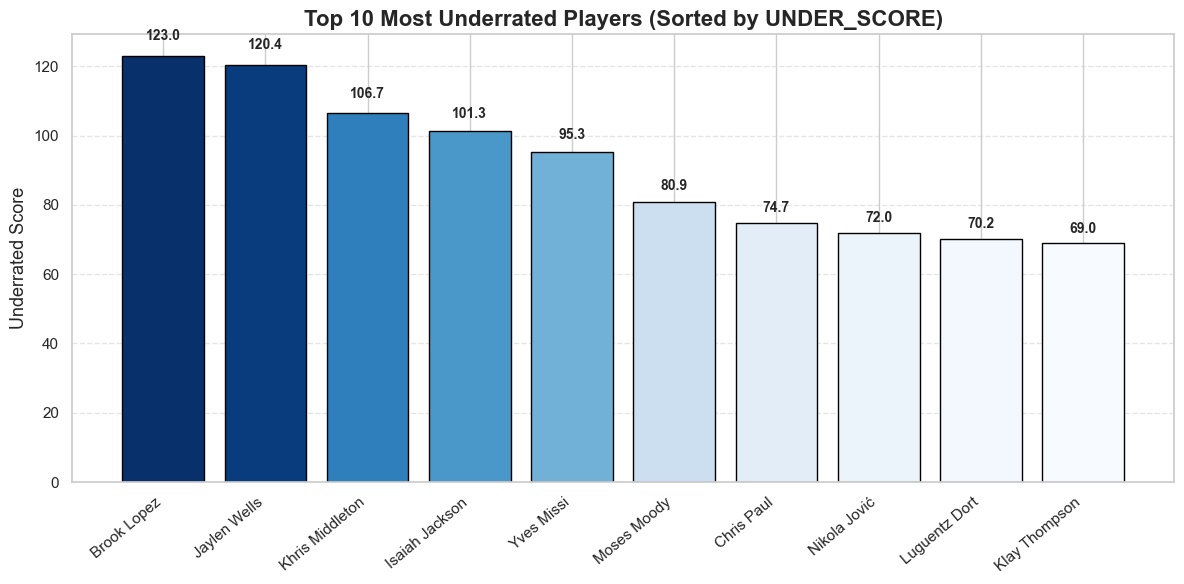

In [87]:
# Sort dataframe by underrated score (descending)
df_sorted = df_underrated.sort_values("UNDER_SCORE", ascending=False)

# Extract values
scores = df_sorted["UNDER_SCORE"]
players = df_sorted["Player Name"]

plt.figure(figsize=(12,6))

# Create gradient colors based on score
colors = plt.cm.Blues((scores - scores.min()) / (scores.max() - scores.min()))

# Draw bars
bars = plt.bar(players, scores, color=colors, edgecolor='black', linewidth=1)

# Axis labels and title
plt.xticks(rotation=40, ha="right", fontsize=11)
plt.ylabel("Underrated Score", fontsize=13)
plt.title("Top 10 Most Underrated Players (Sorted by UNDER_SCORE)", fontsize=16, fontweight='bold')

# Add horizontal grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels above each bar
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y + (y * 0.03),
        f"{round(y, 1)}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**Methodology**

To identify the most underrated players, we use the metric UNDER_SCORE, which measures how much a player’s actual on-court performance (PERF_SCORE, NBA_FANTASY_PTS, and key stats) exceeds what their ownership percentage (% Owned) would predict.

If a player produces much more than their ownership would suggest → High UNDER_SCORE → Underrated

If a player produces less relative to ownership → Low UNDER_SCORE → Overrated

This approach captures hidden value players who are consistently productive but not widely rostered.

**Key Insights**

**1. Brook Lopez**

- Highest UNDER_SCORE overall.
- Strong defensive stats (BLK) + efficient scoring, yet ownership remains lower than performance suggests.

**2. Jaylen Wells**
- Extremely high impact for his expected fantasy relevance.
- Outperforms typical bench/low-roster players.

**3. Khris Middleton**
- Strong across-the-board contributions despite injuries lowering his perceived value.
- Ownership undervalues his stable production.

## 4-2. Question 2. Which Stats Predict Ownership the Best?
**Goal:** Analyze which performance stats (e.g., points, assists, rebounds) are most closely related to a player's ownership percentage in fantasy leagues. This will help determine which stats drive fantasy managers to pick players.

In [88]:
# Select columns for correlation analysis
cols = ["% Owned", "PTS", "REB", "AST", "STL", "BLK", "TOV", "FG_PCT", "FT_PCT", "FG3M"]

# Compute correlation matrix for the selected columns
corr = df_final[cols].corr()
corr

,% Owned,PTS,REB,AST,STL,BLK,TOV,FG_PCT,FT_PCT,FG3M
% Owned,1.000000,0.504515,0.362595,0.352103,0.260763,0.188567,0.388070,0.188820,0.181561,0.135781
PTS,0.504515,1.000000,0.526314,0.679142,0.540785,0.240954,0.764071,0.073288,0.325060,0.658090
REB,0.362595,0.526314,1.000000,0.344352,0.417413,0.600234,0.536330,0.391677,-0.045632,0.074258
AST,0.352103,0.679142,0.344352,1.000000,0.552571,0.028855,0.762518,-0.068091,0.156348,0.427471
STL,0.260763,0.540785,0.417413,0.552571,1.000000,0.223229,0.482202,0.020409,0.095999,0.406807
BLK,0.188567,0.240954,0.600234,0.028855,0.223229,1.000000,0.228620,0.291769,-0.078940,0.010639
TOV,0.388070,0.764071,0.536330,0.762518,0.482202,0.228620,1.000000,0.060529,0.168694,0.416394
FG_PCT,0.188820,0.073288,0.391677,-0.068091,0.020409,0.291769,0.060529,1.000000,-0.115302,-0.345981
FT_PCT,0.181561,0.325060,-0.045632,0.156348,0.095999,-0.078940,0.168694,-0.115302,1.000000,0.371890
FG3M,0.135781,0.658090,0.074258,0.427471,0.406807,0.010639,0.416394,-0.345981,0.371890,1.000000


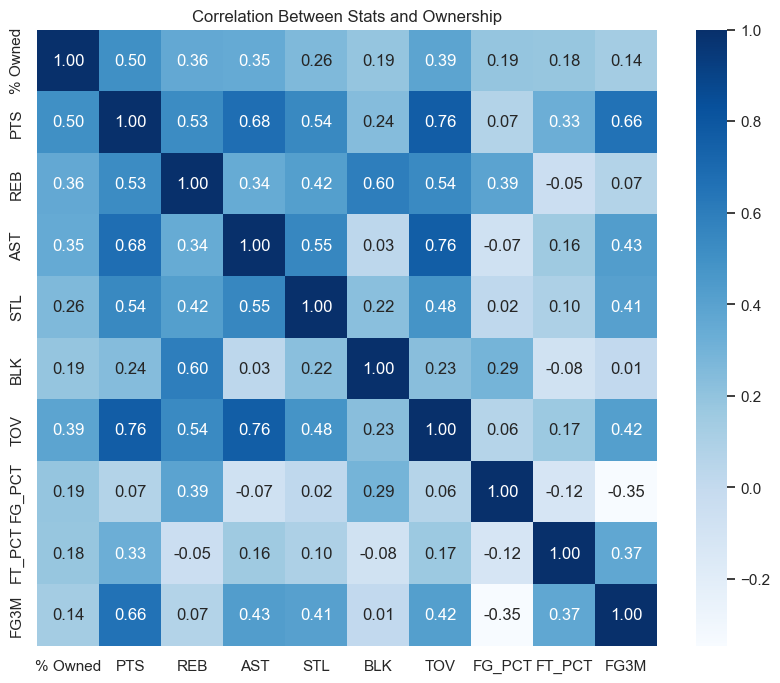

In [89]:
# create a new figure and set its size (width=10, height=8 inches)
plt.figure(figsize=(10,8))
# draw a heatmap of the correlation matrix with annotations, blue color map, and 2-decimal formatting
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
# set the title of the heatmap plot
plt.title("Correlation Between Stats and Ownership")
plt.show()

The correlation analysis shows that **Points (PTS)** are the strongest predictor of fantasy ownership. Players who score at high volume are consistently rostered, which reflects the central role of scoring in fantasy evaluations.

Following points, **Turnovers (TOV)** surprisingly show the second highest correlation with ownership. This does not mean turnovers increase ownership, but rather that high usage players who handle the ball frequently, naturally accumulate more turnovers. It is a proxy effect: the more a player is involved in offensive creation, the more likely they are to be rostered.

**Rebounds (REB)** and **Assists (AST)** also demonstrate moderate correlations. These are core counting stats that contribute steady value across formats, and players who excel in them tend to attract consistent fantasy interest.

**Steals (STL)** show a moderate correlation as well, reflecting their scarcity and overall importance in category leagues.

By contrast, percentage-based metrics such as **FG%** and **FT%** show weak correlations with ownership. Efficiency metrics depend heavily on context (usage, volume, role), and thus fantasy managers generally prioritize counting stats over efficiency.

Finally, **Three-Pointers Made (FG3M)** shows one of the weakest correlations with ownership. While three point shooting is important in fantasy, many specialists contribute primarily in this single category without offering broader production, which limits their overall ownership rates.

Overall, the data indicates that high-usage, multi-category contributors, particularly strong scorers—are the most consistently rostered players in fantasy leagues.

## 4-3. Question 3. Which Draft Picks Became the Biggest Steals or Busts?
**Goal:** Analyze which performance stats (e.g., points, assists, rebounds) are most closely related to a player's ownership percentage in fantasy leagues. This will help determine which stats drive fantasy managers to pick players.

In [90]:
df_temp = df_final.copy()

# Calculate draft round (assuming a 12-team league)
# Formula: pick 1–12 → round 1, 13–24 → round 2, etc.
df_temp['Draft Round'] = ((df_temp['Draft Pick'] - 1) // 12) + 1

# Compute the average PERF_SCORE for each draft round
# This represents the expected performance for players picked in the same round
round_mean = df_temp.groupby('Draft Round')['PERF_SCORE'].mean()

# Map the expected round performance back to each player
# Creates a baseline (expected value) based on their draft round
df_temp['Expected Round Score'] = df_temp['Draft Round'].map(round_mean)

# Calculate the "true" value gap
# Value Gap = Actual Performance - Expected Performance (based on round)
df_temp['Value Gap True'] = df_temp['PERF_SCORE'] - df_temp['Expected Round Score']

# Identify the Top 10 Steals (players who outperformed round expectations the most)
steals = df_temp.sort_values('Value Gap True', ascending=False).head(10)

# Identify the Top 10 Busts (players who underperformed round expectations the most)
busts = df_temp.sort_values('Value Gap True').head(10)

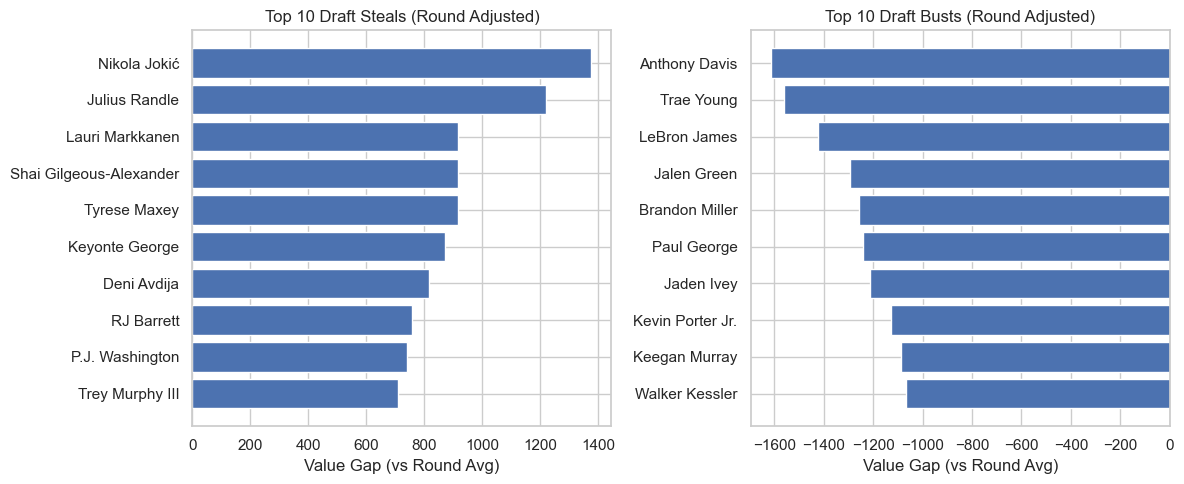

In [91]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.barh(steals['Player Name'], steals['Value Gap True'])
plt.title("Top 10 Draft Steals (Round Adjusted)")
plt.xlabel("Value Gap (vs Round Avg)")
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
plt.barh(busts['Player Name'], busts['Value Gap True'])
plt.title("Top 10 Draft Busts (Round Adjusted)")
plt.xlabel("Value Gap (vs Round Avg)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**Methodology**

Instead of comparing players by raw draft pick, each player’s performance (PERF_SCORE) is compared to the average performance of players drafted in the same round.

- If a player performs far above their round’s average → Steal
- If a player performs below their round’s average → Bust

This method removes the bias that normally pushes early-round stars to the top of “best picks” lists and makes the comparison fair between rounds.

**Top Steals**

Players like Nikola Jokić, Julius Randle, and Lauri Markkanen delivered far higher performance than the average player from their draft round. These were the most efficient picks and provided strong surplus value.

**Top Busts**

Players such as Anthony Davis, Trae Young, and LeBron James produced well below the expected level for their draft rounds, making them the most costly underperformers.

**Interesting Finding** : **Julius Randle** ranks as the second-biggest steal despite being drafted at pick 67, a relatively low position. His performance score was far above the average for players taken in the same round, showing that he delivered exceptional surplus value compared to expectations.

## 4-4. Question 4. Which Teams Produce the Most Valuable Fantasy Players?
**Goal:** Determine which NBA teams produce the highest value fantasy players (based on stats like fantasy points, rebounds, assists, etc.). This will help fantasy managers target players from these teams for better fantasy results.

In [92]:
# Compute the average performance score (PERF_SCORE) for each NBA team
team_value = (
    df_temp.groupby("NBA Team")["PERF_SCORE"] # group players by their NBA team
    .mean() # compute the average performance score for each team
    .sort_values(ascending=False) # sort from highest to lowest value
)

/var/folders/h2/jlfpcp4133qgyb_brlp5xfvm0000gn/T/ipykernel_51520/330507527.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


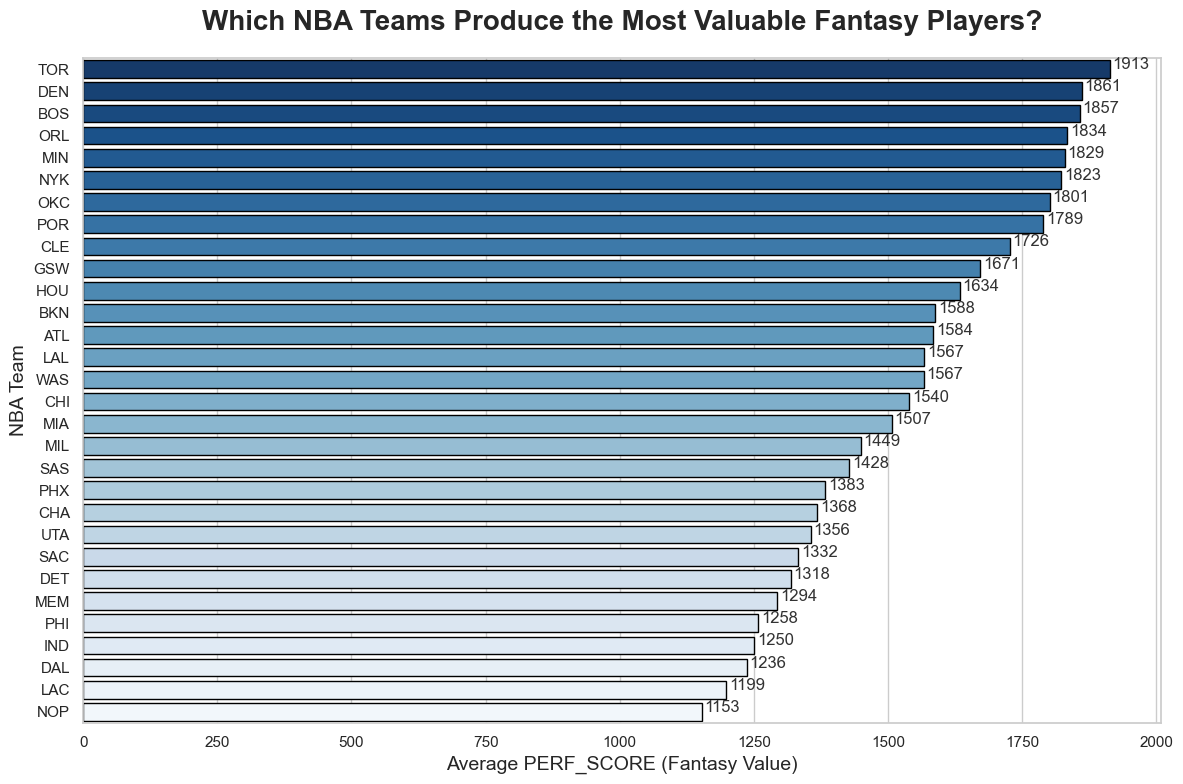

In [93]:
# Set the visualization style using seaborn
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

# Draw a horizontal barplot of team performance values
bars = sns.barplot(
    x=team_value.values,
    y=team_value.index,
    palette="Blues_r",   # 예쁜 블루 그라데이션
    edgecolor="black"
)

#  Set plot title and axis labels with styling
plt.title("Which NBA Teams Produce the Most Valuable Fantasy Players?", 
          fontsize=20, fontweight="bold", pad=20)
plt.xlabel("Average PERF_SCORE (Fantasy Value)", fontsize=14)
plt.ylabel("NBA Team", fontsize=14)

# Add numeric value labels on the right side of each bar
for i, v in enumerate(team_value.values):
    plt.text(v + 5, i, f"{v:.0f}", fontsize=12, color="#333333")

# Adjust padding and layout so elements are not cut off
plt.tight_layout()

plt.show()

**Top Performing Teams**

**Toronto (TOR)**, **Denver (DEN)**, and **Boston (BOS)** lead the league in average fantasy value.
These teams feature multiple high impact players who contribute across several categories, which boosts their overall team-wide fantasy output.

**Orlando (ORL)**, **Minnesota (MIN)**, and **New York (NYK)** also rank highly, indicating strong depth and well-rounded player production.

These teams are strong targets for fantasy managers because they consistently develop players who generate high all-around value.

# **4. Summary & Reflection**

I chose these two datasets because I’ve always been interested in understanding how fantasy basketball decisions are made on Yahoo Fantasy, where metrics like ownership percentage and draft data reflect how real users evaluate NBA players. It felt meaningful to **connect on-court performance with fantasy manager behavior**.

The most challenging part of this project was the **data acquisition**. Setting up OAuth for the Yahoo Fantasy API took much longer than I expected, and figuring out where each piece of data ownership, draft results, player metadata, was located required a lot of trial and error. Normally, most of my time goes into data cleaning, but for this assignment, retrieving the data itself was the hardest and most time consuming step.

I was also surprised by the list of underrated players. Several names like **Brook Lopez** and **Isaiah Jackson** ranked much higher than I expected, and their actual fantasy impact was greater than their ownership rates suggested. **It was interesting to see how perception and performance can differ so much.**

If I continue this project, I’d like to explore value trends over tim, such as whether ownership patterns shift during the season, or **build a predictive model for identifying undervalued players before they break out**. There is a lot of potential to deepen the analysis of how fantasy managers behave and how accurately they evaluate real performance.